# Predict

Run prediction using the model output from [02_modelling.ipynb](./02_modelling.ipynb)

Output: [nisjedata-substrat-xgbclassifier_norge_latest_25833.geojson](https://storage.googleapis.com/niva-geodata/MarintNaturKart/nisjedata-substrat-xgbclassifier_norge_latest_25833.geojson)

Comparison map [here](https://terriamap.p.niva.no/#start=%7B%22version%22%3A%228.0.0%22%2C%22initSources%22%3A%5B%7B%22stratum%22%3A%22user%22%2C%22models%22%3A%7B%22__User-Added_Data__%22%3A%7B%22isOpen%22%3Atrue%2C%22members%22%3A%5B%228245f6bc-c3d0-4fcc-aeaa-10faad0a3ec1%22%5D%2C%22knownContainerUniqueIds%22%3A%5B%22%2F%22%5D%2C%22type%22%3A%22group%22%7D%2C%22%2F%2FMarint+Natur+Kart%2FTest+Hard%2FL%C3%B8s%2FBlanding+Prediksjon+-+Norge%22%3A%7B%22splitDirection%22%3A1%2C%22knownContainerUniqueIds%22%3A%5B%22%2F%2FMarint+Natur+Kart%22%5D%2C%22type%22%3A%22wfs%22%7D%2C%22%2F%2FMarint+Natur+Kart%2FBunntypeklasser+for+Prediksjon+Norge%22%3A%7B%22splitDirection%22%3A-1%2C%22knownContainerUniqueIds%22%3A%5B%22%2F%2FMarint+Natur+Kart%22%5D%2C%22type%22%3A%22wfs%22%7D%2C%228245f6bc-c3d0-4fcc-aeaa-10faad0a3ec1%22%3A%7B%22splitSourceItemId%22%3A%22%2F%2FMarint+Natur+Kart%2FTest+Hard%2FL%C3%B8s%2FBlanding+Prediksjon+-+Norge%22%2C%22dereferenced%22%3A%7B%22name%22%3A%22Test+Hard%2FL%C3%B8s%2FBlanding+Prediksjon+-+Norge+%28copy%29%22%2C%22splitDirection%22%3A-1%7D%2C%22knownContainerUniqueIds%22%3A%5B%22__User-Added_Data__%22%5D%2C%22type%22%3A%22split-reference%22%7D%2C%22%2F%22%3A%7B%22type%22%3A%22group%22%7D%2C%22%2F%2FMarint+Natur+Kart%22%3A%7B%22knownContainerUniqueIds%22%3A%5B%22%2F%22%5D%2C%22type%22%3A%22group%22%7D%7D%2C%22workbench%22%3A%5B%22%2F%2FMarint+Natur+Kart%2FTest+Hard%2FL%C3%B8s%2FBlanding+Prediksjon+-+Norge%22%2C%22%2F%2FMarint+Natur+Kart%2FBunntypeklasser+for+Prediksjon+Norge%22%5D%2C%22timeline%22%3A%5B%22%2F%2FMarint+Natur+Kart%2FTest+Hard%2FL%C3%B8s%2FBlanding+Prediksjon+-+Norge%22%5D%2C%22initialCamera%22%3A%7B%22west%22%3A-1.8237304687500002%2C%22south%22%3A60.31062731740045%2C%22east%22%3A18.665771484375004%2C%22north%22%3A65.29346780107583%7D%2C%22homeCamera%22%3A%7B%22west%22%3A4%2C%22south%22%3A57.00000000000001%2C%22east%22%3A32%2C%22north%22%3A72%7D%2C%22viewerMode%22%3A%222d%22%2C%22showSplitter%22%3Atrue%2C%22splitPosition%22%3A0.5%2C%22settings%22%3A%7B%22baseMaximumScreenSpaceError%22%3A2%2C%22useNativeResolution%22%3Afalse%2C%22alwaysShowTimeline%22%3Afalse%2C%22baseMapId%22%3A%22basemap-openstreetmap%22%2C%22terrainSplitDirection%22%3A0%2C%22depthTestAgainstTerrainEnabled%22%3Afalse%7D%2C%22stories%22%3A%5B%5D%7D%5D%7D)

In [1]:
from pathlib import Path

import geopandas as gpd
import geoutils as gu
import numpy as np
import pandas as pd
import rasterio as rio
import xdem
from osgeo import gdal, ogr, osr

import subkart

In [2]:
RESOLUTION = 50
nodata = 255
crs = "EPSG:25833"

In [3]:
classifier = subkart.utils.load_classifier()

# Predict for Norge

## Wave Exposure


In [5]:
bolge = subkart.sources.bolge_exposure()


## DEM 50

In [6]:
dem_norge = subkart.sources.dem_data()

## Predict

In [ ]:
reverse_map = {v: k for k, v in subkart.labelling.BUNNTYPE_MAPPING.items()}
for region_name, region_list in subkart.sources.REGIONS.items():
    print(f"Processing region: {region_name}")
    gdf_sea_map_region = subkart.sources.sea_map_basisdata(region_list)
    gdf_sea_map_region = subkart.features.depth_preprocess(gdf_sea_map_region)
    transform, out_shape, bounds = subkart.features.to_raster_shapes(gdf_sea_map_region, res=RESOLUTION)
    dem_region = subkart.utils.resample_dem(dem_norge.crop(bounds), out_shape, transform, crs)

    X, valid_attrs, out_shape, transform = subkart.features.build(
        dem_region, gdf_sea_map_region, bolge, valid_mask=None, res=RESOLUTION, dtype=np.float16
    )
    print("Predict ...")
    Y_pred = classifier.predict(X)

    pred_map = np.full(out_shape, nodata, dtype=np.uint8)
    pred_map[valid_attrs] = Y_pred.astype(np.uint8)

    # Mask nodata values explicitly to avoid the warning
    pred_map_masked = np.ma.masked_equal(pred_map, nodata)

    pred_raster = gu.Raster.from_array(pred_map_masked, transform=transform, crs=crs, nodata=nodata)
    fname = f"{region_name}_prediction.tif"
    pred_raster.to_file(Path(fname))
    print(f"Saved prediction for region {region_name} to {fname}\n")

Processing region: vestland
Preparing sea_avg_depth...


/home/kim/work/marint-naturkart-nivaR/.pixi/envs/default/lib/python3.13/site-packages/geoutils/raster/raster.py:1822: UserWarning: Setting default nodata -99999 to mask non-finite values found in the array, as no nodata value was defined.
  warnings.warn(


Preparing sea_avg_slope...


/home/kim/work/marint-naturkart-nivaR/.pixi/envs/default/lib/python3.13/site-packages/geoutils/raster/raster.py:1822: UserWarning: Setting default nodata -99999 to mask non-finite values found in the array, as no nodata value was defined.
  warnings.warn(


Preparing sea_compactness...


...

Preparing sea_compactness...


/home/kim/work/marint-naturkart-nivaR/.pixi/envs/default/lib/python3.13/site-packages/geoutils/raster/raster.py:1822: UserWarning: Setting default nodata -99999 to mask non-finite values found in the array, as no nodata value was defined.
  warnings.warn(


Preparing sea_convexity...


/home/kim/work/marint-naturkart-nivaR/.pixi/envs/default/lib/python3.13/site-packages/geoutils/raster/raster.py:1822: UserWarning: Setting default nodata -99999 to mask non-finite values found in the array, as no nodata value was defined.
  warnings.warn(


Preparing marine types...
Stacking feature arrays...
Predict ...
Saved prediction for region nord to nord_prediction.tif



## Post processing

In [ ]:
gdal.UseExceptions()
fname = "norge_merged.tif"
input_files = [f"{region_name}_prediction.tif" for region_name in subkart.sources.REGIONS.keys()]

subkart.utils.merge_rasters(input_files, fname, nodata=nodata)


In [9]:
def create_raw_polygons(input_raster, output_gpkg, epsg_code, nodata=255):
    # 1. Open source and read array
    ds = gdal.Open(input_raster)
    band = ds.GetRasterBand(1)
    arr = band.ReadAsArray()

    # 2. Recombine by priority (2 > 1 > 0)
    # Start with a clean array of 0s (or your lowest priority)
    final_labels = np.full(arr.shape, nodata, dtype=np.uint8)
    for val in [0, 1, 2]:
        final_labels[arr == val] = val

    # 3. Create In-Memory Raster
    drv_mem = gdal.GetDriverByName("Mem")
    mem_ds = drv_mem.Create("", ds.RasterXSize, ds.RasterYSize, 1, gdal.GDT_Byte)
    mem_ds.SetGeoTransform(ds.GetGeoTransform())
    mem_ds.SetProjection(ds.GetProjection())

    mem_band = mem_ds.GetRasterBand(1)
    mem_band.WriteArray(final_labels)

    # --- THE MASKING STEP ---
    # Create a boolean mask: 1 for data we want, 0 for data to ignore (255)
    mask_arr = (final_labels != nodata).astype(np.uint8)
    mask_ds = drv_mem.Create("", ds.RasterXSize, ds.RasterYSize, 1, gdal.GDT_Byte)
    mask_band = mask_ds.GetRasterBand(1)
    mask_band.WriteArray(mask_arr)
    # ------------------------

    # 4. Prepare GeoPackage
    srs = osr.SpatialReference()
    srs.ImportFromEPSG(epsg_code)

    drv_gpkg = ogr.GetDriverByName("GPKG")
    out_ds = drv_gpkg.CreateDataSource(output_gpkg)
    out_layer = out_ds.CreateLayer("polys", srs=srs, geom_type=ogr.wkbPolygon)
    out_layer.CreateField(ogr.FieldDefn("DN", ogr.OFTInteger))

    # 5. Polygonize with the Mask Band
    # Argument 2 is the mask band. Only pixels where mask_band == 1 are processed.
    gdal.Polygonize(mem_band, mask_band, out_layer, 0, [], callback=None)

    # Cleanup
    mem_ds = None
    mask_ds = None
    out_ds = None
    ds = None
    print(f"Polygons saved to {output_gpkg}")


# Example
create_raw_polygons("norge_merged.tif", "polygons_raw.gpkg", int(crs.split(":")[1]), nodata=255)

Polygons saved to polygons_raw.gpkg


In [10]:
gdf_raw = gpd.read_file("polygons_raw.gpkg")

In [11]:
fname = subkart.utils.to_filename(
    f"nisjedata-substrat-{classifier.__class__.__name__.lower()}", "norge", "latest", gdf_raw.crs.to_epsg()
)
# Map raster_value (0/1) to BunnType using existing mapping_values
reverse_map = {v: k for k, v in subkart.labelling.BUNNTYPE_MAPPING.items()}
gdf_raw["BunnType"] = gdf_raw["DN"].map(reverse_map)
gdf_raw.to_file(f"{fname}.gpkg", driver="GPKG", layer="bunntyper")
gdf_raw.to_parquet(f"{fname}.geo.parquet", compression="snappy")
subkart.utils.to_postgis(gdf_raw, fname)

Table nisjedata_substrat_xgbclassifier_norge_latest uploaded to PostGIS.


# Predict for AOI - 2025 

Playground area used in 2025

In [12]:
gdf_sea_map = subkart.sources.sea_map_basisdata(["More_og_Romsdal"])
gdf_sea_map = subkart.features.depth_preprocess(gdf_sea_map)
transform, out_shape, bounds = subkart.features.to_raster_shapes(gdf_sea_map, res=RESOLUTION)
crs = gdf_sea_map.crs

In [13]:
gdf_sea_map_more = subkart.features.depth_preprocess(gdf_sea_map)

All depth features already present, skipping preprocessing.


In [14]:
# bolge already loaded above


In [15]:
gdf_bunn_moere = gpd.read_file(
    "https://storage.googleapis.com/niva-geodata/MarintNaturKart/2025aoi/bunn_in_kommuner_sea.geojson"
)
gdf_clip = gdf_bunn_moere.to_crs(gdf_sea_map_more.crs)

vec_clip = gu.Vector(gdf_clip)

In [16]:
# marine_vanntyper overlay removed - wave exposure is raster-based


In [17]:
clipped_gdf = gdf_clip.overlay(gdf_sea_map_more)

In [18]:
transform, out_shape, bounds = subkart.features.to_raster_shapes(clipped_gdf, res=RESOLUTION)
dem = xdem.DEM(
    rio.open("https://storage.googleapis.com/niva-geodata/MarintNaturKart/input/kartverket/dem50_vestland.tif")
)
dem = subkart.utils.resample_dem(dem, out_shape, transform, crs)

In [19]:
X, valid_attrs, out_shape, transform = subkart.features.build(
    dem, clipped_gdf, bolge, valid_mask=None, res=RESOLUTION, dtype=np.float16
)

Preparing sea_avg_depth...


/home/kim/work/marint-naturkart-nivaR/.pixi/envs/default/lib/python3.13/site-packages/geoutils/raster/raster.py:1822: UserWarning: Setting default nodata -99999 to mask non-finite values found in the array, as no nodata value was defined.
  warnings.warn(


Preparing sea_avg_slope...


/home/kim/work/marint-naturkart-nivaR/.pixi/envs/default/lib/python3.13/site-packages/geoutils/raster/raster.py:1822: UserWarning: Setting default nodata -99999 to mask non-finite values found in the array, as no nodata value was defined.
  warnings.warn(


Preparing sea_compactness...


/home/kim/work/marint-naturkart-nivaR/.pixi/envs/default/lib/python3.13/site-packages/geoutils/raster/raster.py:1822: UserWarning: Setting default nodata -99999 to mask non-finite values found in the array, as no nodata value was defined.
  warnings.warn(


Preparing sea_convexity...


/home/kim/work/marint-naturkart-nivaR/.pixi/envs/default/lib/python3.13/site-packages/geoutils/raster/raster.py:1822: UserWarning: Setting default nodata -99999 to mask non-finite values found in the array, as no nodata value was defined.
  warnings.warn(


Preparing marine types...
Stacking feature arrays...


In [20]:
Y_pred = classifier.predict(X)

In [21]:
pred_map = np.full(out_shape, np.nan, dtype=np.float32)
pred_map[valid_attrs] = Y_pred.astype(np.float32)

In [22]:
pred_raster = gu.Raster.from_array(pred_map, transform=transform, crs=crs)

/home/kim/work/marint-naturkart-nivaR/.pixi/envs/default/lib/python3.13/site-packages/geoutils/raster/raster.py:1822: UserWarning: Setting default nodata -99999 to mask non-finite values found in the array, as no nodata value was defined.
  warnings.warn(


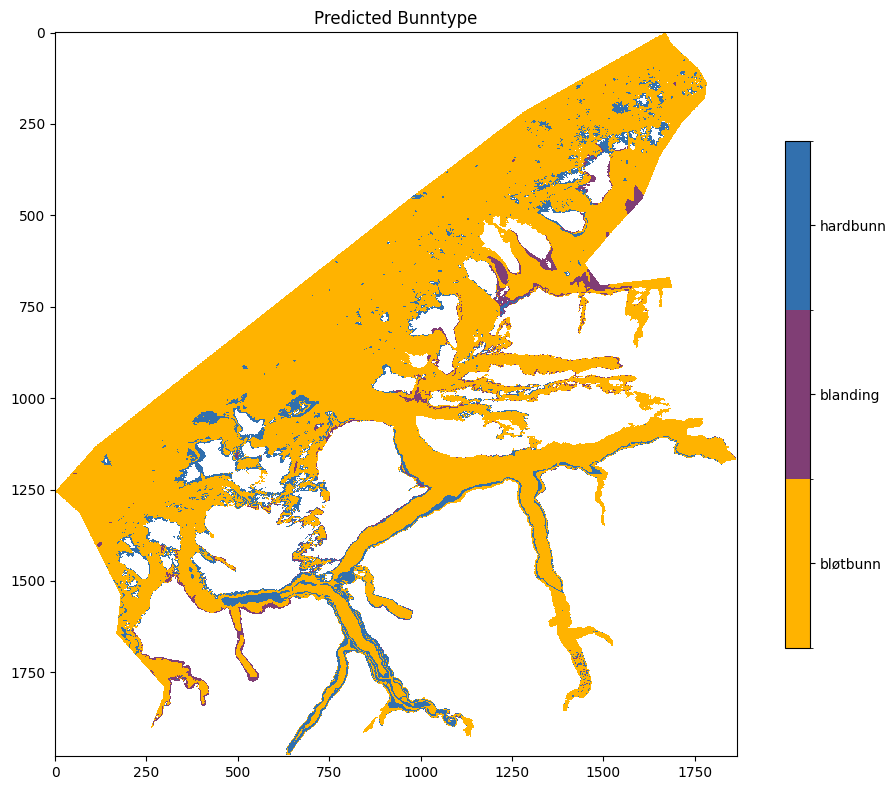

In [23]:
subkart.plot.prediction_raster(pred_raster)

# Vectorize output

In [43]:
pred_vec = pred_raster.polygonize()

/home/kim/work/marint-naturkart-nivaR/.venv/lib/python3.11/site-packages/geoutils/interface/raster_vector.py:102: RuntimeWarning: invalid value encountered in cast
  shapes(source_raster.data.astype(final_dtype), mask=bool_msk, transform=source_raster.transform)


In [ ]:
pred_vec["BunnType"] = pred_vec["raster_value"].map(reverse_map)

pred_vec["BunnType"]

0         løsbunn
1        fastbunn
2        blanding
3         løsbunn
4         løsbunn
           ...   
10053     løsbunn
10054    fastbunn
10055    fastbunn
10056    fastbunn
10057    fastbunn
Name: BunnType, Length: 10058, dtype: object

In [ ]:
gdf_final = pred_vec.ds.to_crs("EPSG:25833")
fname = subkart.utils.to_filename(
    f"nisjedata-substrat-{classifier.__class__.__name__.lower()}",
    "aoi-moere-og-romsdal",
    "latest",
    gdf_final.crs.to_epsg(),
)
gdf_final = gdf_final.drop(columns=["depth_range", "class"], errors="ignore")
gdf_final.to_file(f"{fname}.geojson", driver="GeoJSON")